# Employee Satisfaction Analysis at Fiktiva

This notebook is a portfolio project looking at an HR dataset. The data is a synthetic file of 700 employees from a fictional company called Fiktiva, given to us as part of a university data analysis course.

The main question I want to answer is: **which employee characteristics seem to be related to employee satisfaction, and what data quality issues should I be aware of before trusting those results?**

This dataset was built for a data analysis exercise rather than for prediction, so I'll focus on getting the data quality and EDA right and drawing solid conclusions from it. I'll go through the following stages:

1. understanding the dataset and checking data quality,
2. cleaning and preparing the data,
3. running plausibility checks,
4. exploratory analysis on focused questions,
5. summarising findings, limitations and next steps.

## 1. Import libraries and load the dataset

I'll start with the essential libraries:

- `pandas` for data manipulation,
- `matplotlib.pyplot` for charts,
- `re`, just for a small check on the employee IDs later on.

I also set a clean default chart style so the visual output stays consistent throughout the notebook.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# load the dataset
employees = pd.read_csv('datasets/employees_satisfaction.csv', index_col=0)

# first look at the data
employees.head()

,emp_id,age,Dept,education,recruitment_type,job_level,rating,awards,certifications,salary,gender,entry_date,last_raise,satisfied
0,HR8270,28,HR,PG,Referral,5,2,1,0,86750,m,2019-02-01,NaN,1
1,TECH1860,50,Technology,PG,Recruitment Agency,3,5,2,1,42419,Male,2017-01-17,NaN,0
2,TECH6390,43,Technology,UG,Referral,4,1,2,0,65715,f,2012-08-27,NaN,1
3,SAL6191,44,Sales,PG,On-Campus,2,3,0,0,29805,f,2017-07-25,NaN,1
4,HR6734,33,HR,UG,Recruitment Agency,2,1,5,0,29805,m,2019-05-17,NaN,1


## 2. Understand the dataset

I'll start with the basics: shape, column names, types, basic stats and missing values. The goal is to figure out early if there's anything that needs fixing before I start cleaning or plotting.

In [3]:
print(f'Number of rows and columns: \n{employees.shape}')
print('='*40)
print(f'Column names:\n{employees.columns.to_list()}')
print('='*40)
print(f'Type of columns:\n{employees.dtypes}')
print('='*40)
print(f'Statistics from the table:\n{employees.describe()}')
print('='*40)
print(f'Number of empty values per column:\n{employees.isna().sum()}')

Number of rows and columns: 
(700, 14)
Column names:
['emp_id', 'age', 'Dept', 'education', 'recruitment_type', 'job_level', 'rating', 'awards', 'certifications', 'salary', 'gender', 'entry_date', 'last_raise', 'satisfied']
Type of columns:
emp_id                  str
age                   int64
Dept                    str
education               str
recruitment_type        str
job_level             int64
rating                int64
awards                int64
certifications        int64
salary                int64
gender                  str
entry_date              str
last_raise          float64
satisfied             int64
dtype: object
Statistics from the table:
              age   job_level      rating      awards  certifications  \
count  700.000000  700.000000  700.000000  700.000000      700.000000   
mean    39.855714    3.095714    3.082857    4.545714        0.507143   
std      8.532394    1.423584    1.414818    2.982432        0.594400   
min     23.000000    1.000000    1

### Initial observations

This dataset already gives a decent amount of business-relevant info: department, age, education, job level, salary, performance rating, awards, certifications and whether someone is satisfied or not.

A few things stand out from this first look:

1. `last_raise` has 595 missing values out of 700, so more than 80%. That's way too much to fill in reasonably - I'll just drop this column.
2. `gender` has only 6 missing values, which is small but I still need to decide what to do with them.
3. `entry_date` is stored as text right now, so I'll need to convert it to an actual date before I can do anything with years.
4. Looking at `awards` and `certifications`, the max values look way higher than the rest of the distribution (25 and 9), so I'll come back to those in the plausibility checks section.

## 3. Clean and prepare the data

Cleaning isn't just about making the code run - it's about making the numbers trustworthy later on.

For this dataset I'll:
1. rename `Dept` to `department`, since that's clearer,
2. convert `entry_date` to an actual datetime,
4. check the categories in the text columns and fix anything that's written in more than one way (e.g. `m` vs `Male`),
5. decide what to do with the missing values in `gender` and `last_raise`,
6. create an `entry_year` column, which I'll use a few times in the EDA.

In [4]:
# rename Dept to department, easier to read
employees = employees.rename(columns={'Dept': 'department'})
employees.columns

Index(['emp_id', 'age', 'department', 'education', 'recruitment_type',
       'job_level', 'rating', 'awards', 'certifications', 'salary', 'gender',
       'entry_date', 'last_raise', 'satisfied'],
      dtype='str')

In [5]:
# convert entry_date to an actual date
employees['entry_date'] = pd.to_datetime(employees['entry_date'])
employees['entry_date'].head()

0   2019-02-01
1   2017-01-17
2   2012-08-27
3   2017-07-25
4   2019-05-17
Name: entry_date, dtype: datetime64[us]

### Checking categorical columns

I want to see all the unique values in the text columns, to catch anything written inconsistently.

In [6]:
# check the categories in every text column except emp_id, which is just an identifier
for col in employees.columns:
    if pd.api.types.is_string_dtype(employees[col]) and col != 'emp_id':
        print(f'The column {col} has the following categories: \n{employees[col].unique()}')
        print('-'*40)

The column department has the following categories: 
<StringArray>
['HR', 'Technology', 'Sales', 'Purchasing', 'Marketing']
Length: 5, dtype: str
----------------------------------------
The column education has the following categories: 
<StringArray>
['PG', 'UG']
Length: 2, dtype: str
----------------------------------------
The column recruitment_type has the following categories: 
<StringArray>
['Referral', 'Recruitment Agency', 'On-Campus', 'Walk-in']
Length: 4, dtype: str
----------------------------------------
The column gender has the following categories: 
<StringArray>
['m', 'Male', 'f', 'Female', nan]
Length: 5, dtype: str
----------------------------------------


This shows two things to fix:

- In `gender`, women show up as both `f` and `Female`, and men as both `m` and `Male`. I'll merge those.
- In `education`, `UG` and `PG` mean Undergraduate and Postgraduate, so I'll write them out in full to make the charts easier to read later.

In [7]:
# merge the gender categories that mean the same thing
employees['gender'] = employees['gender'].replace({'m': 'Male', 'f': 'Female'})
employees['gender'].value_counts(dropna=False)

gender
Male      364
Female    330
NaN         6
Name: count, dtype: int64

In [8]:
# write education levels in full
employees['education'] = employees['education'].replace({'UG': 'Undergraduate', 'PG': 'Postgraduate'})
employees['education'].unique()

<StringArray>
['Postgraduate', 'Undergraduate']
Length: 2, dtype: str

### Dealing with the missing gender values

Only 6 rows out of 700 are missing here, less than 1%. I could just drop these rows since it's such a small amount, but gender is one of the things I'll look at in the EDA, so instead I'll label them as `'Unknown'` - that way I keep those 6 employees visible as their own small group rather than losing them completely.

In [9]:
# fill the missing gender values with 'Unknown' instead of dropping the rows
employees['gender'] = employees['gender'].fillna('Unknown')
employees['gender'].value_counts()

gender
Male       364
Female     330
Unknown      6
Name: count, dtype: int64

### Dropping last_raise

`last_raise` is missing for more than 80% of the rows (674 out of 700). That's far too much to fill in reliably or to use as a feature, so I'll just drop it.

In [10]:
# drop last_raise, too many missing values to be useful
employees = employees.drop(columns='last_raise')
employees.head()

,emp_id,age,department,education,recruitment_type,job_level,rating,awards,certifications,salary,gender,entry_date,satisfied
0,HR8270,28,HR,Postgraduate,Referral,5,2,1,0,86750,Male,2019-02-01,1
1,TECH1860,50,Technology,Postgraduate,Recruitment Agency,3,5,2,1,42419,Male,2017-01-17,0
2,TECH6390,43,Technology,Undergraduate,Referral,4,1,2,0,65715,Female,2012-08-27,1
3,SAL6191,44,Sales,Postgraduate,On-Campus,2,3,0,0,29805,Female,2017-07-25,1
4,HR6734,33,HR,Undergraduate,Recruitment Agency,2,1,5,0,29805,Male,2019-05-17,1


### Adding an entry_year column

I'll use this a few times later, both in the plausibility checks (to estimate how old people were when they joined) and in the EDA (to compare satisfaction across different "generations" of employees).

In [11]:
# extract the year someone joined, will be useful later on
employees['entry_year'] = employees['entry_date'].dt.year
employees[['entry_date', 'entry_year']].head()

,entry_date,entry_year
0,2019-02-01,2019
1,2017-01-17,2017
2,2012-08-27,2012
3,2017-07-25,2017
4,2019-05-17,2019


## 4. Plausibility checks

Before trusting any chart, I want to make sure the values in the table actually make sense. For this dataset I'll check:

1. whether the employee ID prefix matches the department (e.g. someone with an ID starting with `SAL` should be in Sales),
2. whether `emp_id` is actually unique for every employee,
3. whether `awards` and `certifications` contain any values that look like data entry mistakes,
4. how old people were when they joined the company, to spot anyone who would've joined as a child.

### Checking employee ID vs department

Each `emp_id` starts with a few letters before the numbers, and those letters look like a department code (e.g. `SAL` for Sales, `TECH` for Technology). I'll check that this prefix always matches the `department` column - if it doesn't, that's a sign of either a data entry error or a department change that wasn't reflected everywhere.

In [12]:
# map of ID prefixes to department names
prefix_to_department = {
    'HR': 'HR',
    'TECH': 'Technology',
    'SAL': 'Sales',
    'MKT': 'Marketing',
    'FIN': 'Finance',
    'PUR': 'Purchasing',
}

mismatches = 0
for emp_id, department in zip(employees['emp_id'], employees['department']):
    prefix = re.sub(r'\d+', '', emp_id)  # remove the digits to get just the letters
    if prefix_to_department.get(prefix) != department:
        mismatches += 1

print(f'Number of ID/department mismatches: {mismatches} out of {len(employees)} rows')

Number of ID/department mismatches: 0 out of 700 rows


Every single ID prefix matches the department, so this part of the data looks internally consistent.

### Checking for duplicate employee IDs

`emp_id` is supposed to uniquely identify each employee, so I'd expect 700 unique values - one per row.

In [13]:
# are there any duplicate employee IDs?
print(f"Number of rows: {len(employees)}")
print(f"Number of unique emp_id values: {employees['emp_id'].nunique()}")

employees[employees['emp_id'].duplicated(keep=False)]

Number of rows: 700
Number of unique emp_id values: 699


,emp_id,age,department,education,recruitment_type,job_level,rating,awards,certifications,salary,gender,entry_date,satisfied,entry_year
188,MKT7287,41,Marketing,Undergraduate,Referral,2,5,0,1,29805,Female,2014-04-07,1,2014
215,MKT7287,50,Marketing,Postgraduate,Referral,2,2,1,0,29805,Male,2013-08-01,0,2013


There's one `emp_id` (`MKT7287`) that appears twice, for two employees in Marketing with different ages and satisfaction values - so this looks like a genuine duplicate ID rather than the same row twice. I can't tell which of the two has the "correct" ID, and I'll assume both rows represent real, distinct employees and just leave them as they are - I don't use `emp_id` for anything beyond this check anyway.

### Checking awards and certifications

Both `awards` and `certifications` had maximum values that looked far away from the rest of the distribution in the `describe()` table from section 2, so I want to look at those columns specifically.

In [14]:
print(employees['awards'].value_counts().sort_index())
print('-'*40)
print(employees['certifications'].value_counts(dropna=False))

awards
0     72
1     63
2     71
3     74
4     67
5     76
6     71
7     62
8     65
9     78
25     1
Name: count, dtype: int64
----------------------------------------
certifications
0    353
1    346
9      1
Name: count, dtype: int64


`awards` goes from 0 to 9 for almost everyone, with one employee at 25. That's a big jump (about 7 standard deviations above the mean), but it's not impossible - someone could simply be a long-tenured top performer who's collected a lot of recognitions. Without more context I can't fully confirm it either way, so I'll keep this value as it is.

`certifications` on the other hand should only be 0 or 1 (certified or not), but one row has a value of 9. I can't think of a legitimate reason for that, so I think this is a typo - most likely someone meant to type `0` and an extra `9` slipped in. I'll correct that single value to `0` rather than leaving it or dropping the row, since the rest of that row's data looks fine.

In [15]:
# fix the 9 in certifications, most likely a typo for 0
employees.loc[employees['certifications'] == 9, 'certifications'] = 0
employees['certifications'].value_counts()

certifications
0    354
1    346
Name: count, dtype: int64

### How old were people when they joined?

I don't have a "year of birth" column, but I can estimate it from `age` (assuming "today" is equal to the year of the last hire - 2025) and compare it with `entry_year`. If someone's estimated entry age comes out below, say, 16, that's worth a look.

In [16]:
# rough estimate of how old someone was when they joined
employees['entry_age'] = employees['entry_year'] - (2025 - employees['age'])

under_16 = employees[employees['entry_age'] < 16]
print(f"Number of employees with an estimated entry age below 16: {len(under_16)} ({len(under_16)/len(employees)*100:.1f}% of the dataset)")

Number of employees with an estimated entry age below 16: 0 (0.0% of the dataset)


Good - nobody in the dataset would have joined the company before turning 16, so this check passes and there's nothing to clean up here.

## 5. Exploratory analysis

Now for the EDA part. The goal isn't to prove anything, just to look for patterns that could be useful for HR. I'll go through these questions:

1. What's the overall satisfaction rate?
2. Does satisfaction vary by department?
3. Does satisfaction vary by job level?
4. Does satisfaction vary by performance rating?
5. Does satisfaction vary by recruitment type?
6. Is salary different between satisfied and unsatisfied employees?
7. Does satisfaction vary depending on when someone joined the company?

### 5.1 Overall satisfaction rate

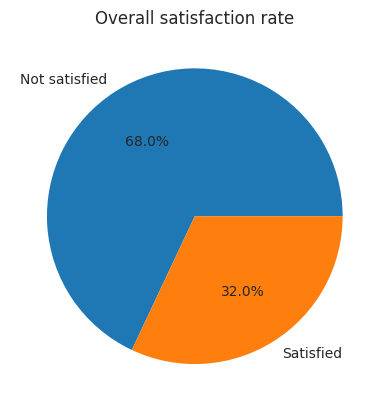

In [17]:
satisfaction_counts = employees['satisfied'].value_counts()
satisfaction_counts.plot(kind='pie', autopct='%1.1f%%', labels=['Not satisfied', 'Satisfied'])
plt.title('Overall satisfaction rate')
plt.ylabel('')
plt.show()

68% of employees say they're satisfied, against 32% who don't. That's a reasonably healthy baseline, but it still leaves about a third of the workforce unsatisfied, so it's worth checking whether this is spread evenly or concentrated in specific groups.

### 5.2 Satisfaction by department

department
Sales         77.235772
Technology    68.750000
HR            67.567568
Purchasing    66.666667
Marketing     61.151079
Name: satisfied, dtype: float64


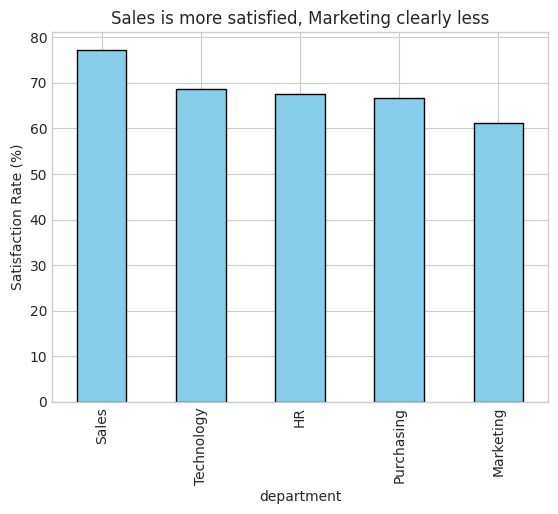

In [18]:
satisfaction_by_department = employees.groupby('department')['satisfied'].mean().sort_values(ascending=False) * 100
print(satisfaction_by_department)

satisfaction_by_department.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Sales is more satisfied, Marketing clearly less')
plt.ylabel('Satisfaction Rate (%)')
plt.show()

Sales comes out on top at around 77%, while Marketing is clearly the lowest at around 61% - roughly a 16 point gap. The other three departments (Technology, HR, Purchasing) all sit in a fairly tight band around 67-69%. This is the clearest difference I've found so far in this dataset, so if I had to pick one thing to flag to HR first, it would be this.

### 5.3 Satisfaction by job level

job_level
1    70.312500
2    72.661871
3    69.047619
4    63.157895
5    65.806452
Name: satisfied, dtype: float64


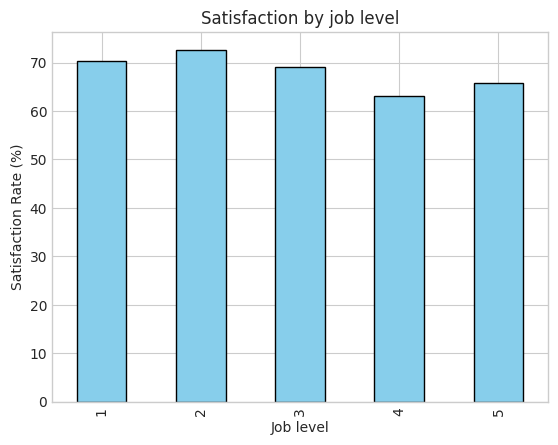

In [19]:
satisfaction_by_level = employees.groupby('job_level')['satisfied'].mean() * 100
print(satisfaction_by_level)

satisfaction_by_level.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Satisfaction by job level')
plt.xlabel('Job level')
plt.ylabel('Satisfaction Rate (%)')
plt.show()

I don't see a strong trend here - satisfaction sits between roughly 63% and 73% across levels, with no obvious "the higher the level, the happier" pattern. Level 4 stands out a bit as the lowest (around 63%), which could be a mid-career frustration point, but the rest of the levels are close enough to each other that I wouldn't call this a strong signal. On its own, job level doesn't seem to say much about satisfaction.

### 5.4 Satisfaction by performance rating

rating
1    68.217054
2    69.565217
3    67.716535
4    63.291139
5    71.621622
Name: satisfied, dtype: float64


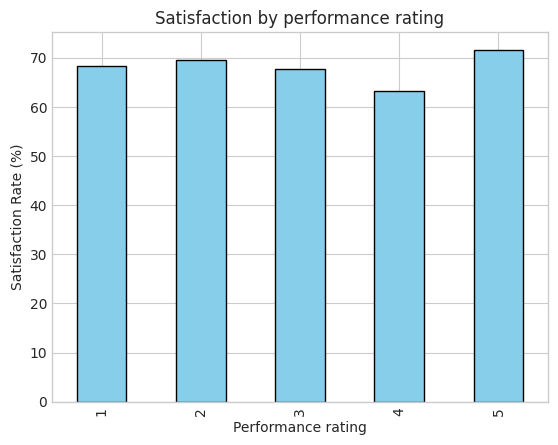

In [20]:
satisfaction_by_rating = employees.groupby('rating')['satisfied'].mean() * 100
print(satisfaction_by_rating)

satisfaction_by_rating.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Satisfaction by performance rating')
plt.xlabel('Performance rating')
plt.ylabel('Satisfaction Rate (%)')
plt.show()

This one surprised me - I expected satisfaction to increase with performance rating, but it really doesn't. Satisfaction stays in a tight 64-70% band across ratings 1 to 4, and rating 5 employees are actually the *most* satisfied (around 72%), but rating 4 employees are the *least* satisfied (around 63%) - so there's no clean increasing or decreasing pattern at all. Being a "good performer" on paper clearly isn't the main thing driving satisfaction in this dataset.

### 5.5 Satisfaction by recruitment type

recruitment_type
Walk-in               75.806452
On-Campus             70.394737
Recruitment Agency    66.379310
Referral              63.020833
Name: satisfied, dtype: float64


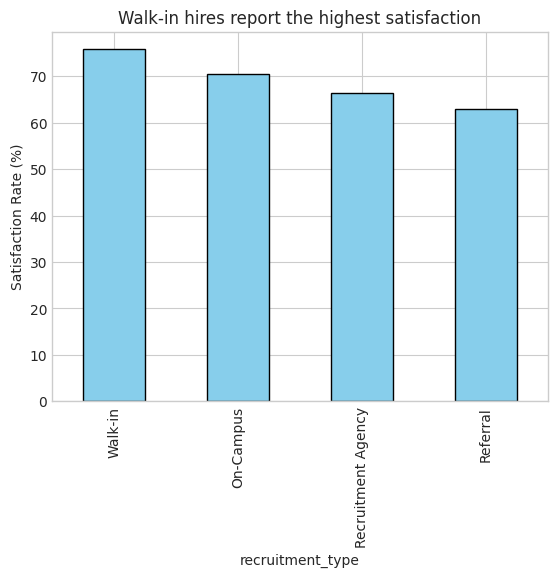

In [21]:
satisfaction_by_recruitment = employees.groupby('recruitment_type')['satisfied'].mean().sort_values(ascending=False) * 100
print(satisfaction_by_recruitment)

satisfaction_by_recruitment.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Walk-in hires report the highest satisfaction')
plt.ylabel('Satisfaction Rate (%)')
plt.show()

Walk-in hires have the highest satisfaction (around 76%), Referrals the lowest (around 63%), with about a 13 point gap between them. On-Campus and Recruitment Agency sit in between, closer to Walk-in than to Referral. I would have guessed referrals to be at least average, since people referred by current employees usually have a better idea of what they're getting into - so this is a bit counter-intuitive and probably worth a closer look.

### 5.6 Salary, satisfied vs not satisfied

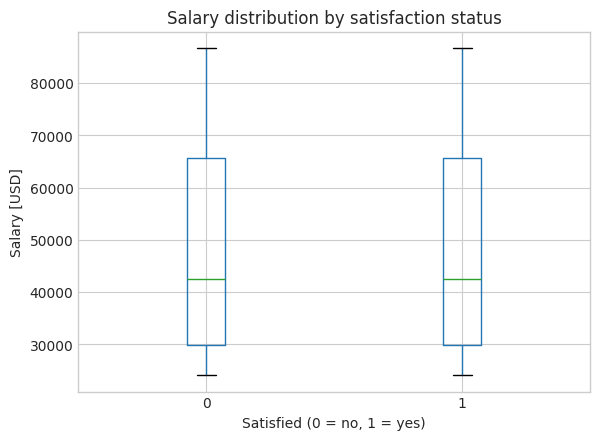

Median salary:
 satisfied
0    42419.0
1    42419.0
Name: salary, dtype: float64
Average salary:
 satisfied
0    53480.397321
1    50472.138655
Name: salary, dtype: float64


In [22]:
employees.boxplot(column='salary', by='satisfied')
plt.title('Salary distribution by satisfaction status')
plt.suptitle('')
plt.xlabel('Satisfied (0 = no, 1 = yes)')
plt.ylabel('Salary [USD]')
plt.show()

print(f'Median salary:\n {employees.groupby('satisfied')['salary'].median()}')
print('='*40)
print(f'Average salary:\n {employees.groupby('satisfied')['salary'].mean()}')

The salary distributions for satisfied and unsatisfied employees look very similar, and the median salary is actually identical for both groups (around 42,500 USD). The mean tells a slightly different story though - it's a bit higher for unsatisfied employees (around 53,500 USD) than for satisfied ones (around 50,500 USD), which suggests there might be a handful of high earners on the unsatisfied side pulling the mean up. Either way, salary doesn't look like a strong, direct driver of satisfaction here - similar to what I found for job level and rating.

### 5.7 Satisfaction by entry year

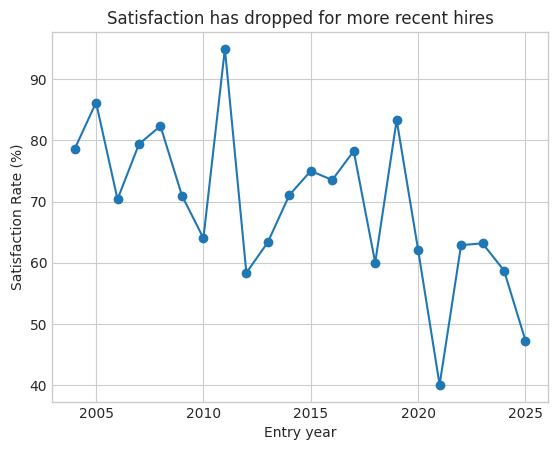

In [23]:
satisfaction_by_year = employees.groupby('entry_year')['satisfied'].mean() * 100

satisfaction_by_year.plot(kind='line', marker='o')
plt.title('Satisfaction has dropped for more recent hires')
plt.xlabel('Entry year')
plt.ylabel('Satisfaction Rate (%)')
plt.show()

This is the second clear pattern I found, and actually the biggest gap of all: employees who joined in 2021 or later report around 54% satisfaction on average, against around 74% for employees who joined before that - about a 20 point difference. Looking year by year there's a lot of noise (some early years have very few employees, so a couple of unhappy people can swing the percentage a lot - 2021 itself is at 40% and 2025 at around 47%), but the drop for the last few cohorts as a group is large and consistent enough that I don't think it's just noise. Combined with the department finding, this feels like the most "actionable" part of the EDA - something changed for newer hires (or for Marketing) that's worth investigating outside of this dataset.

## 6. Summary, limitations and next steps

**Findings**: overall, 68% of employees say they're satisfied. Of everything I looked at, the entry-year cohort shows the biggest gap (around 74% for employees who joined before 2021, vs around 54% for those who joined since), followed by department (Sales at 77% vs Marketing at 61%, ~16 points) and recruitment type (Walk-in at 76% vs Referral at 63%, ~13 points). `job_level`, `rating` and `salary`, on the other hand, showed no clear relationship with satisfaction at all - the percentages barely move across categories.

So if I had to summarise this in one sentence for HR: the "soft" factors around when and how someone joined, and which department they're in, seem to matter a lot more for satisfaction than career numbers like salary, level or performance rating.

**Limitations**:
- This is a synthetic dataset of 700 fictional employees from a university exercise, so the patterns found here describe this dataset only and shouldn't be read as facts about real companies.
- `certifications` had one clear data entry error (a value of 9 where only 0/1 makes sense), which I corrected to 0 assuming it was a typo - I didn't end up using this column much in the EDA anyway, but it's worth flagging the assumption.
- There's one duplicate `emp_id` (two different employees sharing the same ID) - I kept both rows since looking at other features it looks like they represent different employees.
- This is descriptive, not causal - e.g. I can say Marketing has lower satisfaction and recent hires are less satisfied, but not why. Both would need more context (interviews, exit surveys, etc.) to actually explain.
- Some of the entry-year cohorts have very few employees, so their percentages are based on small samples and can be noisy.

**Next steps**:
- If I wanted to dig further with the tools I have here, I could look at department and recruitment type together (e.g. is the Marketing/low-satisfaction effect spread evenly across recruitment types, or concentrated in one of them?).
- I'd want to understand why recent hires are less satisfied - this would mean going beyond this dataset, e.g. talking to HR about any changes around 2021 (onboarding process, management changes, pay policy, etc.).
- If this were a real company, I'd suggest a short follow-up survey focused on Marketing and on employees who joined in the last few years, since those are the two groups where something seems to be going on.